# EDA

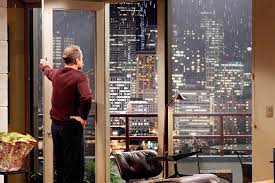

In [44]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

In [38]:
df = pd.read_csv(
    "data/king_county_housing_clean.csv",
    parse_dates=["date"]
)

df["zipcode"] = df["zipcode"].astype("category")

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21597 non-null  int64         
 1   bedrooms       21597 non-null  float64       
 2   bathrooms      21597 non-null  float64       
 3   sqft_living    21597 non-null  float64       
 4   sqft_lot       21597 non-null  float64       
 5   floors         21597 non-null  float64       
 6   waterfront     21597 non-null  int64         
 7   view           21597 non-null  int64         
 8   condition      21597 non-null  int64         
 9   grade          21597 non-null  int64         
 10  sqft_above     21597 non-null  float64       
 11  sqft_basement  21597 non-null  float64       
 12  yr_built       21597 non-null  int64         
 13  yr_renovated   21597 non-null  int64         
 14  zipcode        21597 non-null  category      
 15  lat            2159

*************  Price destribution, check Outlier ********************

In [40]:
df['price'].describe()

count     21597.000
mean     540296.574
std      367368.140
min       78000.000
25%      322000.000
50%      450000.000
75%      645000.000
max     7700000.000
Name: price, dtype: float64

*************    ********************

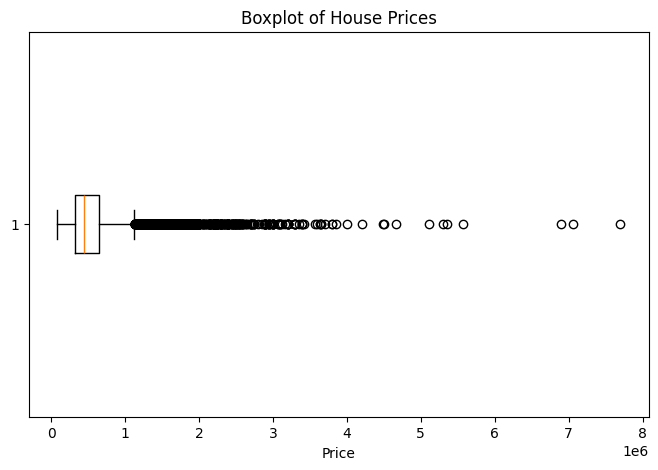

In [41]:
plt.boxplot(df['price'], vert=False)
plt.title('Boxplot of House Prices')
plt.xlabel('Price')
plt.show()

*************  Histogram of House Price ********************

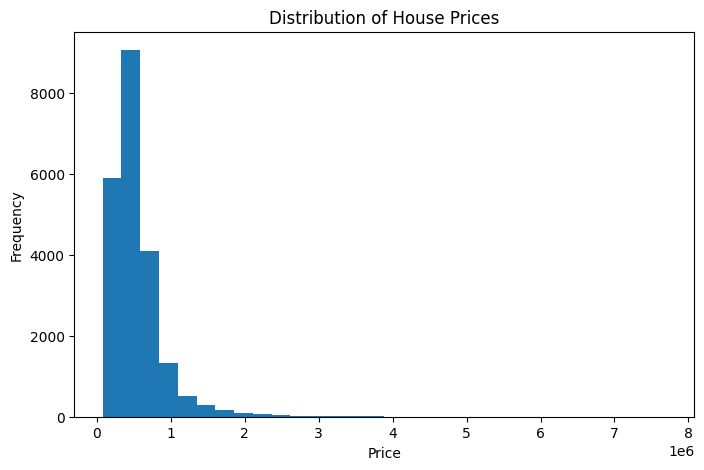

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=30)

plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

*************  renovation status  ********************

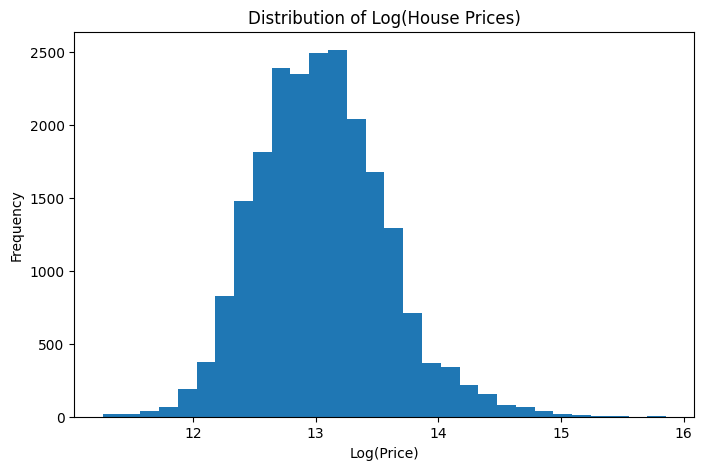

In [45]:
plt.figure(figsize=(8,5))
plt.hist(np.log(df['price']), bins=30)

plt.title('Distribution of Log(House Prices)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.show()

*************  Correlation Matrix for Price  ********************

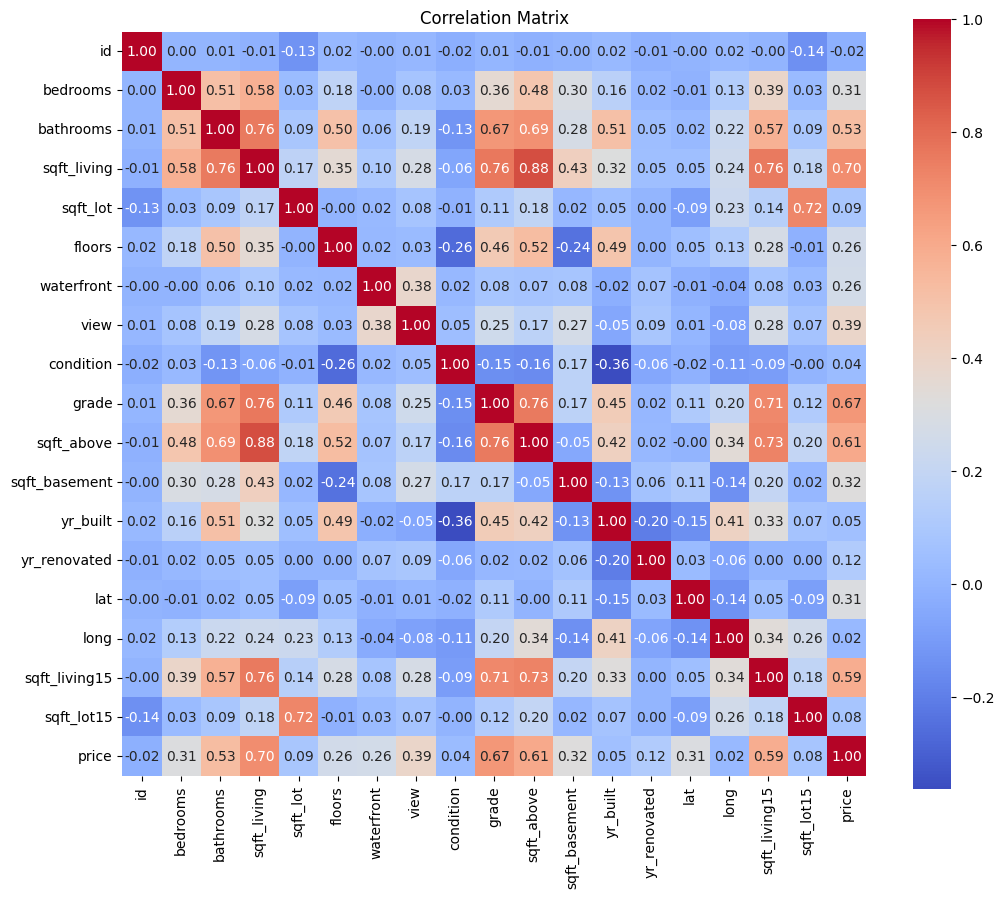

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(12,10))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Matrix")
plt.show()

In [53]:
df_raw = pd.read_csv("data/king_county_housing.csv")

df["yr_renovated"] = df_raw["yr_renovated"]


In [ ]:
df["yr_renovated"].isna().sum()


np.int64(3848)

In [57]:
df["yr_renovated"] = df["yr_renovated"].apply(
    lambda x: x / 10 if pd.notna(x) and x != 0 else x
)

df["yr_renovated"] = df["yr_renovated"].astype("Int64")

In [58]:
df.loc[
    df["yr_renovated"].notna() & (df["yr_renovated"] != 0),
    "yr_renovated"
].head(20)

1      1991
35     2002
95     1991
103    2010
125    1992
158    2013
209    1994
216    1991
230    1978
237    2005
274    2003
282    1994
324    1984
325    1984
330    2002
358    1954
379    2014
398    2011
435    2014
470    1983
Name: yr_renovated, dtype: Int64

*************  Location  ********************

In [59]:
zipcode_price = (
    df.groupby("zipcode")["price"]
      .median()
      .sort_values(ascending=False)
)

zipcode_price.head(10)

zipcode
98039   1895000.000
98004   1150000.000
98040    993750.000
98112    915000.000
98005    765475.000
98006    760184.500
98119    744975.000
98075    739999.000
98109    736000.000
98102    710000.000
Name: price, dtype: float64

In [60]:
zipcode_price.tail(10)

zipcode
98178   278277.000
98148   278000.000
98023   268450.000
98003   267475.000
98198   265000.000
98188   264000.000
98001   260000.000
98032   249000.000
98002   235000.000
98168   235000.000
Name: price, dtype: float64

In [61]:
df.groupby("waterfront")["price"].median()

waterfront
0    450000.000
1   1510000.000
Name: price, dtype: float64

***************** price baseed on Waterfront & living area *************

In [67]:
df["living_size_group"] = pd.cut(
    df["sqft_living"],
    bins=[0, 1500, 2500, 3500, float("inf")],
    labels=[
        "Small (<1500)",
        "Medium (1500–2500)",
        "Large (2500–3500)",
        "Very Large (>3500)"
    ]
)

***************** price per sqft *************

In [77]:
grade_summary = (
    df[df["grade"] != 3]
    .groupby("grade")
    .agg(
        median_price_per_sqft=("price_per_sqft", "median"),
        number_of_houses=("grade", "count")
    )
    .reset_index()
)

grade_summary

,grade,median_price_per_sqft,number_of_houses
0,4,297.260,27
1,5,225.305,242
2,6,241.049,2038
3,7,228.440,8974
4,8,247.126,6065
5,9,254.747,2615
6,10,271.953,1134
7,11,296.296,399
8,12,351.931,89
9,13,450.704,13


In [76]:
grade_summary

,grade,price_per_sqft
0,4,297.260
1,5,225.305
2,6,241.049
3,7,228.440
4,8,247.126
5,9,254.747
6,10,271.953
7,11,296.296
8,12,351.931
9,13,450.704


In [69]:
df["price_per_sqft"] = df["price"] / df["sqft_living"]

In [70]:
grade_price_per_sqft = (
    df.groupby("grade")["price_per_sqft"]
      .median()
      .reset_index()
)

grade_price_per_sqft

,grade,price_per_sqft
0,3,503.846
1,4,297.260
2,5,225.305
3,6,241.049
4,7,228.440
5,8,247.126
6,9,254.747
7,10,271.953
8,11,296.296
9,12,351.931


In [73]:
df[df["grade"] == 3]

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,month,living_size_group,price_per_sqft
3220,2420069251,1.000,0.750,520.000,12981.000,1.000,0,0,5,3,...,98022,47.208,-121.995,1340.000,12233.000,2015-02-25,262000.000,2,Small (<1500),503.846


*************  Location  ********************

In [62]:
df.groupby("view")["price"].median().sort_index()

view
0    433000.000
1    691944.000
2    675000.000
3    802500.000
4   1180000.000
Name: price, dtype: float64

*************  2. Hypothesis  (Renovation )********************

In [63]:
df_renovation = df[df["yr_renovated"].notna()].copy()

df_renovation["renovated"] = (
    df_renovation["yr_renovated"] > 0
)

df_renovation.groupby("renovated")["price"].median()

renovated
False   448000.000
True    607502.000
Name: price, dtype: float64

In [64]:
df.groupby("grade")["price"].median()

grade
3     262000.000
4     200000.000
5     228700.000
6     275276.500
7     375000.000
8     510000.000
9     720000.000
10    914327.000
11   1280000.000
12   1820000.000
13   2980000.000
Name: price, dtype: float64

*************  Location  ********************

In [65]:
df["month"] = df["date"].dt.month

df.groupby("month")["price"].median()

month
1    438500.000
2    426500.000
3    450000.000
4    477000.000
5    462000.000
6    465000.000
7    465000.000
8    442200.000
9    450000.000
10   447000.000
11   435000.000
12   432500.000
Name: price, dtype: float64

*************  Location  ********************